In [11]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier

# Try importing XGBoost
try:
    from xgboost import XGBClassifier
    print("XGBoost is available ✅")
except:
    print("XGBoost not installed ❌")

XGBoost is available ✅


In [12]:
df = pd.read_csv('cleaned_diabetes_data (1).csv')

print("Shape:", df.shape)
df.head()

Shape: (229772, 22)


,Diabetes_012,HighBP,HighChol,CholCheck,BMI,Smoker,Stroke,HeartDiseaseorAttack,PhysActivity,Fruits,...,AnyHealthcare,NoDocbcCost,GenHlth,MentHlth,PhysHlth,DiffWalk,Sex,Age,Education,Income
0,0,1,1,1,40,1,0,0,0,0,...,1,0,5,18,15,1,0,9,4,3
1,0,0,0,0,25,1,0,0,1,0,...,0,1,3,0,0,0,0,7,6,1
2,0,1,1,1,28,0,0,0,0,1,...,1,1,5,30,30,1,0,9,4,8
3,0,1,0,1,27,0,0,0,1,1,...,1,0,2,0,0,0,0,11,3,6
4,0,1,1,1,24,0,0,0,1,1,...,1,0,2,3,0,0,0,11,5,4


In [13]:
X = df.drop('Diabetes_012', axis=1)
y = df['Diabetes_012']

print("Features:", X.shape)
print("Target:", y.shape)

Features: (229772, 21)
Target: (229772,)


In [14]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    stratify=y,
    random_state=42
)

print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)

Train shape: (183817, 21)
Test shape: (45955, 21)


In [15]:
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)

RandomForestClassifier(random_state=42)

In [16]:
importances = rf_model.feature_importances_
features = X.columns

df_imp = pd.DataFrame({
    'Feature': features,
    'Importance': importances
}).sort_values(by='Importance', ascending=False)

df_imp.head(15)

,Feature,Importance
3,BMI,0.184573
18,Age,0.121775
20,Income,0.101845
15,PhysHlth,0.085603
19,Education,0.073241
14,MentHlth,0.064545
13,GenHlth,0.064457
0,HighBP,0.038961
8,Fruits,0.034970
4,Smoker,0.034626


<Figure size 640x480 with 0 Axes>

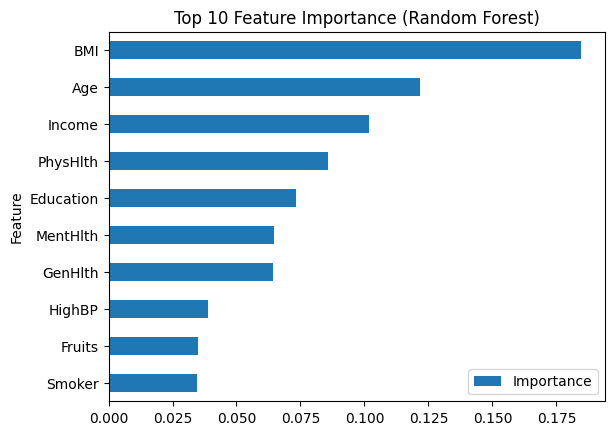

In [17]:
plt.figure()
df_imp.head(10).plot(kind='barh', x='Feature', y='Importance')
plt.title("Top 10 Feature Importance (Random Forest)")
plt.gca().invert_yaxis()
plt.show()

In [18]:
xgb_model = XGBClassifier(use_label_encoder=False, eval_metric='mlogloss')
xgb_model.fit(X_train, y_train)

/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [18:18:52] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='mlogloss',
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=None, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=None, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=None, n_jobs=None,
              num_parallel_tree=None, ...)

In [19]:
importances_xgb = xgb_model.feature_importances_

df_imp_xgb = pd.DataFrame({
    'Feature': X.columns,
    'Importance': importances_xgb
}).sort_values(by='Importance', ascending=False)

df_imp_xgb.head(10)

,Feature,Importance
0,HighBP,0.437264
13,GenHlth,0.129661
1,HighChol,0.085197
2,CholCheck,0.049580
10,HvyAlcoholConsump,0.041875
18,Age,0.034766
3,BMI,0.031236
6,HeartDiseaseorAttack,0.026050
16,DiffWalk,0.022525
17,Sex,0.019572


<Figure size 800x500 with 0 Axes>

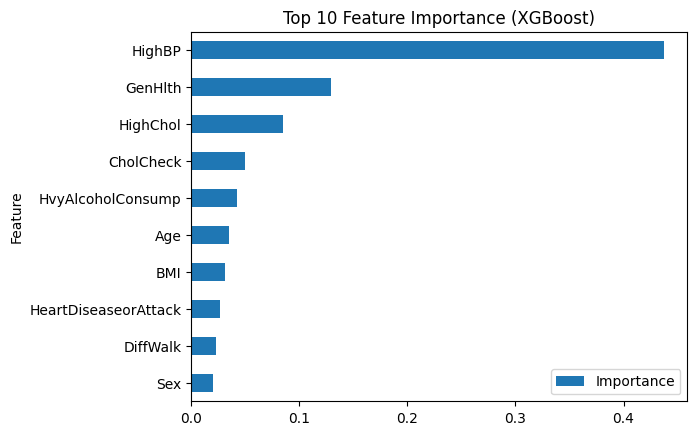

In [20]:
plt.figure(figsize=(8,5))
df_imp_xgb.head(10).plot(kind='barh', x='Feature', y='Importance')
plt.title("Top 10 Feature Importance (XGBoost)")
plt.gca().invert_yaxis()
plt.show()